# Practical 3: Learn a field and assess its proposal

**Learning objective.** Train, save and reload a small field model, then assess its output against a discrete equation and apply a reference correction when needed.

**Predict first.** How will tightening a residual tolerance affect the selected field and use of reference corrections?

<div class="badge-row">
<a class="badge-colab" href="https://colab.research.google.com/github/CEMS-Lab/autumn-school/blob/main/notebooks/study/classroom/03_learning_and_hybrid.ipynb"><img src="../_static/colab-badge.svg" alt="Open in Colab"/></a>
<a class="badge-link" href="../../notebooks/study/classroom/03_learning_and_hybrid.ipynb">Download Practice Notebook</a>
<a class="badge-link" href="../../notebooks/solutions/classroom/03_learning_and_hybrid.ipynb">Download with Worked Solutions</a>
<a class="badge-link" href="../../SETUP.md">Environment Setup</a>
</div>

Work through the cells in order. Expand setup and figure details when you want to inspect the complete implementation.


In [1]:
#@title Set up the course environment { display-mode: "form" }
# Environment setup is measured separately from the classroom computation.
from pathlib import Path
import importlib.metadata
import json
import os
import subprocess
import sys
import time

setup_started = time.perf_counter()
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if not (3, 10) <= sys.version_info[:2] < (3, 13):
    raise RuntimeError("This PhAST snapshot supports Python 3.10–3.12. Select a compatible runtime; see Environment Setup.")

def locate_course_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        for candidate in (base, base / "autumn-school", base / "teaching/ukacm_autumn_school_2026"):
            if (candidate / "notebooks/day2_helpers").is_dir() and (candidate / "vendor/PhAST/src").is_dir():
                return candidate.resolve()
    return None

COURSE_ROOT = locate_course_root()
if COURSE_ROOT is None and IN_COLAB:
    COURSE_ROOT = Path.cwd() / "autumn-school"
    if COURSE_ROOT.exists():
        raise RuntimeError("An incomplete autumn-school folder exists. Start a fresh runtime or select the complete course folder.")
    # A release tag or full commit can be supplied for a fixed course edition.
    course_ref = os.environ.get("PHAST_COURSE_REF", "main")
    subprocess.run(["git", "init", str(COURSE_ROOT)], check=True, capture_output=True)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "remote", "add", "origin", "https://github.com/CEMS-Lab/autumn-school.git"], check=True)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "fetch", "--depth", "1", "origin", course_ref], check=True, timeout=180)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "checkout", "--detach", "FETCH_HEAD"], check=True, capture_output=True)
if COURSE_ROOT is None:
    raise FileNotFoundError("Open the notebook from the complete course folder, including notebooks/, configs/ and vendor/. See Environment Setup.")

if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", str(COURSE_ROOT / "vendor/PhAST"), "nbformat", "nbclient", "nbconvert"], check=True, timeout=600)

for package_dir in (COURSE_ROOT / "vendor/PhAST/src", COURSE_ROOT / "notebooks"):
    if str(package_dir) not in sys.path:
        sys.path.insert(0, str(package_dir))

revision = subprocess.run(["git", "-C", str(COURSE_ROOT), "rev-parse", "HEAD"], text=True, capture_output=True)
package_versions = {}
for package in ("torch", "numpy", "scipy", "matplotlib", "nbformat"):
    try:
        package_versions[package] = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        package_versions[package] = "install using Environment Setup"
import matplotlib.pyplot as plt
import numpy as np
import torch
from io import BytesIO
from IPython.display import Image, display
from day2_helpers import assets_dir

torch.set_default_dtype(torch.float64)
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "font.size": 11, "axes.labelsize": 11, "axes.titlesize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10,
    "figure.titlesize": 13, "figure.dpi": 150, "axes.grid": True,
    "grid.alpha": 0.3, "grid.linestyle": "--", "lines.linewidth": 1.8,
})

def display_figure(figure, dpi=150, alt="Rendered teaching figure"):
    """Retain figures for reading in the book and in a fresh notebook session."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue(), alt=alt))

# Include dependency imports and plotting configuration in the setup duration.
setup_receipt = {
    "environment": "Google Colab" if IN_COLAB else "local",
    "python": sys.version.split()[0],
    "course_revision": revision.stdout.strip() if revision.returncode == 0 else "downloaded archive",
    "versions": package_versions,
    "setup_seconds": round(time.perf_counter() - setup_started, 3),
}
print(setup_receipt)

session_started = time.perf_counter()
torch.set_num_threads(1)

{'environment': 'local', 'python': '3.10.18', 'course_revision': '48ae30794de3da1f4242bfbefff124dfd0d9a594', 'versions': {'torch': '2.8.0', 'numpy': '2.2.6', 'scipy': '1.14.1', 'matplotlib': '3.10.8', 'nbformat': '5.10.4'}, 'setup_seconds': 0.744}


## Physical motivation and model

A learned model can propose a field from coordinates and loading. A discrete equation then provides a second way to inspect that proposal. We practise this relationship using the course-owned **ToyHelmholtzProblem**, a smooth scalar-field model on a $25\times13$ grid:

$$d-\ell^2\nabla^2d=s(x,y,\lambda),\qquad d=0\text{ on the boundary}.$$

Here $d$ is a dimensionless scalar field, $\ell$ is its smoothing length, $s$ is a prescribed source and $\lambda$ is a load factor. Its discrete equation is $A\mathbf d=\mathbf b(\lambda)$. The helper exposes the matrix, source, reference solve and residual. These synthetic fields support teaching model interfaces and correction; applying a learned damage component to fracture requires the fracture-specific inputs, history and coupled residuals.

The workflow is **reference fields → training → saved model → proposal → residual check → selected field**.

## Step-by-step calculation

### Generate whole-load datasets

Each node supplies the row `[x/L, y/H, load_factor]` and one target field value. Keep complete load cases together when dividing training, validation and test data. [Inspect the existing toy and model helpers](https://github.com/CEMS-Lab/autumn-school/blob/main/notebooks/day2_helpers/course_tools.py).

In [2]:
from day2_helpers.course_tools import FEATURE_ORDER, TOY_INTERFACE_VERSION
from day2_helpers.course_tools import TinyDamageMLP, ToyHelmholtzProblem, ToyDamageAdapter
from day2_helpers.course_tools import load_toy_model, normalise_features
torch.manual_seed(20260909)
problem = ToyHelmholtzProblem()
split_loads = {"train": tuple(np.linspace(.12, .76, 12)),
               "validation": (.82, .88), "test": (.94, 1.00)}
train_x, train_y = problem.case_tensor(split_loads["train"])
val_x, val_y = problem.case_tensor(split_loads["validation"])
test_x, test_y = problem.case_tensor(split_loads["test"])
print({"features": tuple(train_x.shape), "targets": tuple(train_y.shape)})

{'features': (3900, 3), 'targets': (3900, 1)}


Inspect complete sample fields from the whole-load splits. Load changes the source amplitude in this teaching equation. Every panel uses the same 0–1 field scale; the NPZ retains the coordinates, split names, loads and shown fields.

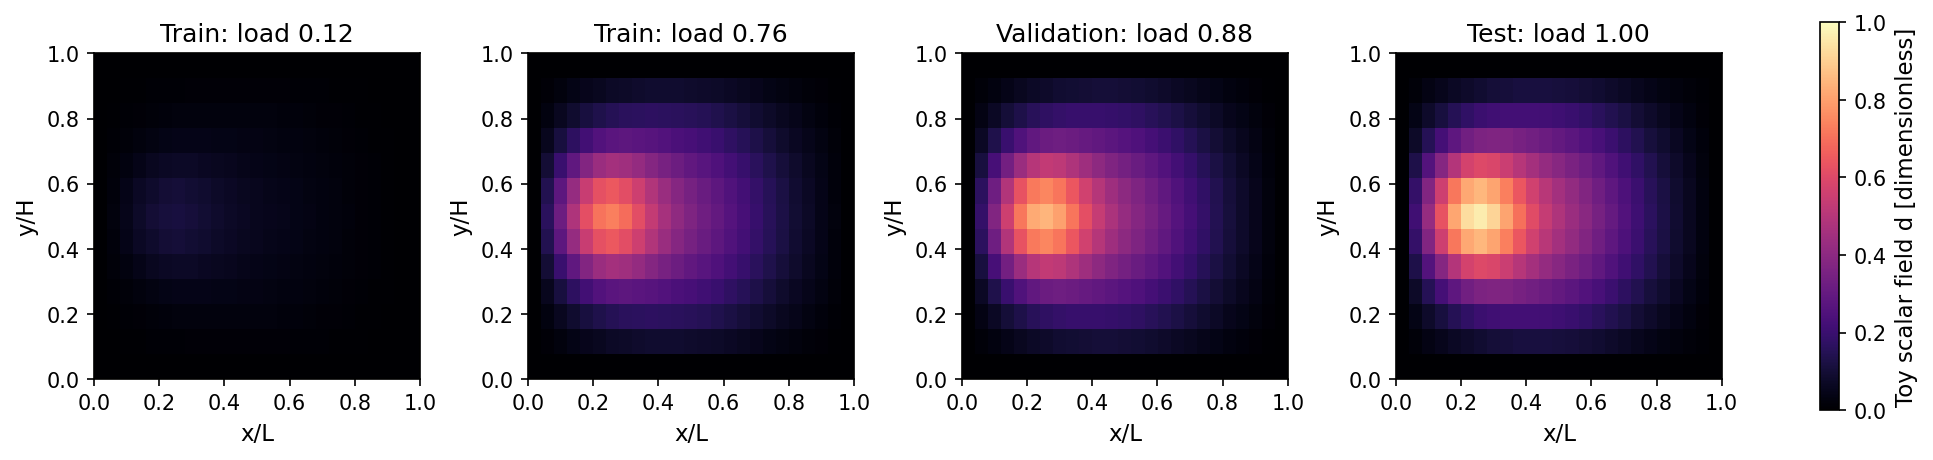

In [3]:
from day2_helpers.classroom_visuals import toy_reference_samples, toy_initial_prediction
from day2_helpers.classroom_visuals import training_snapshot, toy_training_history
practical_dir = assets_dir() / "classroom" / "03"
practical_dir.mkdir(parents=True, exist_ok=True)
fig = toy_reference_samples(problem, split_loads, practical_dir)
display_figure(fig, alt="Full toy reference fields at two training loads, a validation load and a test load on a common colour scale.")
plt.close(fig)

### Define the neural model

Compute the feature mean and scale from the training inputs. Reuse that transform for every split. `TinyDamageMLP` has two hidden layers of width 32 with SiLU activations and a scalar sigmoid output; print its structure to inspect the model.

In [4]:
mean = train_x.mean(dim=0)
scale = train_x.std(dim=0).clamp_min(1.e-12)
model = TinyDamageMLP(width=32).to(dtype=torch.float64)
optimiser = torch.optim.Adam(model.parameters(), lr=1.5e-2)
history = []
print(model)

TinyDamageMLP(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): SiLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): SiLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


Before training, compare the initial model prediction with one training reference field. The model and the source equation produce visibly different spatial patterns at this stage.

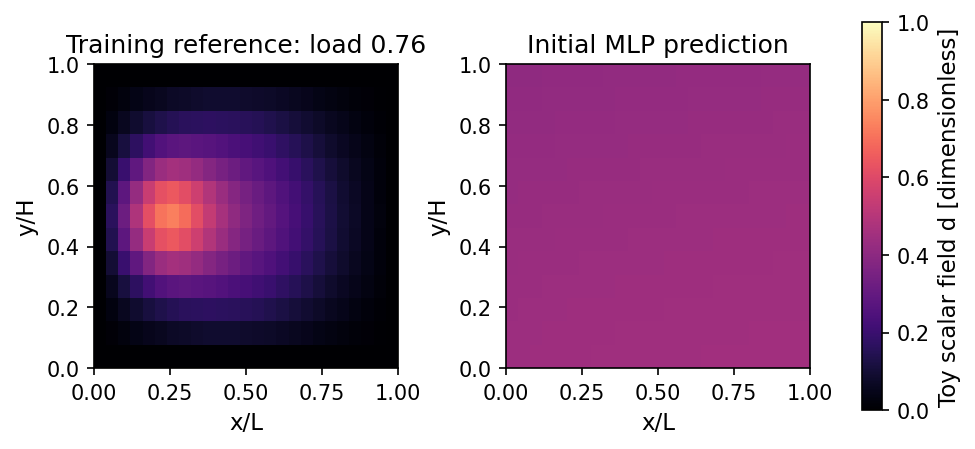

In [5]:
fig = toy_initial_prediction(problem, model, mean, scale, split_loads["train"][-1], practical_dir)
display_figure(fig, alt="Training reference field and initial neural prediction at the same load and colour scale.")
plt.close(fig)

### Train with an inspectable gradient loop

The mean squared error is $\mathcal L=M^{-1}\sum_i(\widehat d_i-d_i)^2$ over the $M$ training rows. `loss.backward()` accumulates gradients of this scalar loss with respect to network weights; Adam updates them. Four snapshots record the training and validation losses. This is the existing 400-epoch teaching calculation.

In [6]:
training_started = time.perf_counter()
for epoch in range(400):
    optimiser.zero_grad(set_to_none=True)
    prediction = model(normalise_features(train_x, mean, scale))
    loss = torch.mean((prediction - train_y) ** 2)
    loss.backward()
    optimiser.step()
    if epoch in {0, 24, 99, 399}:
        history.append(training_snapshot(epoch, loss, model, train_x, train_y, val_x, val_y, mean, scale))
training_seconds = time.perf_counter() - training_started

Read the four recorded snapshots at epochs 1, 25, 100 and 400. Both plotted errors use the same updated model weights. The CSV also retains the original pre-update training loss used by the optimiser; connected markers guide the eye between the four recorded points.

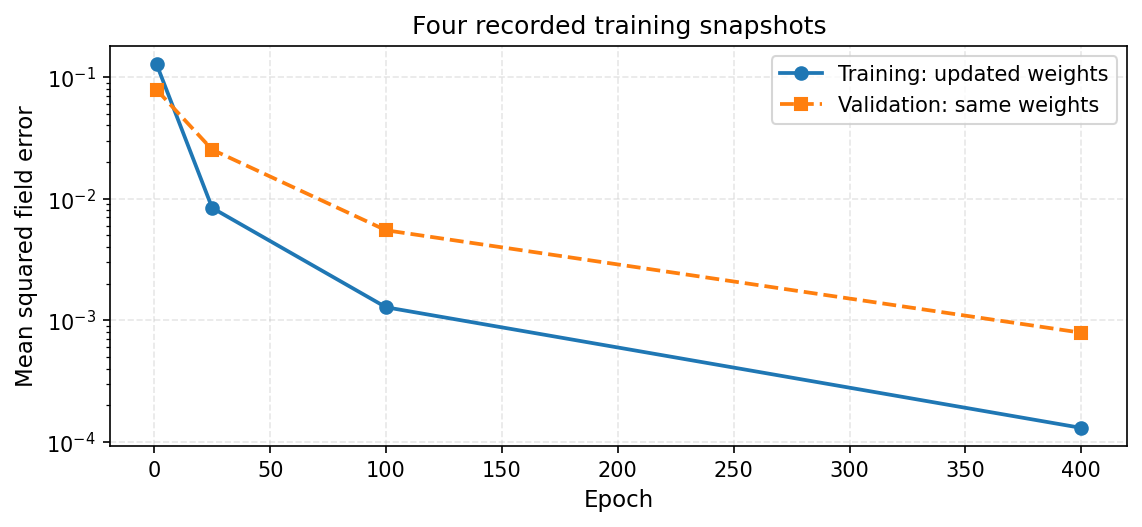

In [7]:
fig = toy_training_history(history, practical_dir)
display_figure(fig, alt="Four matched post-update training and validation mean-squared field-error snapshots.")
plt.close(fig)

Evaluate the held-out data after training. Separate test error, training time and validation history describe different parts of the calculation.

In [8]:
model.eval()
with torch.no_grad():
    test_prediction = model(normalise_features(test_x, mean, scale))
    test_rmse = float(torch.sqrt(torch.mean((test_prediction - test_y) ** 2)))
print({"test_rmse": test_rmse, "training_seconds": round(training_seconds, 2),
       "history": history})

{'test_rmse': 0.049867531488768393, 'training_seconds': 0.87, 'history': [{'epoch': 1, 'train_mse': 0.1517765063048665, 'validation_mse': 0.07862736928885466, 'post_update_train_mse': 0.12749937341629575}, {'epoch': 25, 'train_mse': 0.009012028414098669, 'validation_mse': 0.0252641187641007, 'post_update_train_mse': 0.00838073397708302}, {'epoch': 100, 'train_mse': 0.0012914382086734117, 'validation_mse': 0.005490918863171005, 'post_update_train_mse': 0.0012778083686655118}, {'epoch': 400, 'train_mse': 0.0001303170500437651, 'validation_mse': 0.0007892991355557108, 'post_update_train_mse': 0.00013010943114154136}]}


### Save the model with its input conventions

A usable checkpoint stores architecture, weights, feature order, normalisation and data provenance. Expand the packaging cell to inspect every field. The training and prediction operations above remain unchanged by saving.

In [9]:
practical_dir = assets_dir() / "classroom" / "03"
practical_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = practical_dir / "tiny_damage_mlp.pt"
metadata = {
    "interface_version": TOY_INTERFACE_VERSION, "architecture": "TinyDamageMLP",
    "width": model.width, "feature_order": list(FEATURE_ORDER),
    "feature_location": "node",
    "feature_units": ["dimensionless x/L", "dimensionless y/H", "dimensionless"],
    "output": "toy_damage_proposal at nodes; d=0 intact-like, d=1 saturated",
    "dtype": "float64", "device": "cpu", "mesh_signature": list(problem.mesh_signature),
    "normalisation_mean": mean.tolist(), "normalisation_scale": scale.tolist(),
    "splits": {key: [float(value) for value in values] for key, values in split_loads.items()},
    "data_provenance": "course-owned synthetic fields from the discrete ToyHelmholtzProblem",
    "seed": 20260909, "epochs": 400,
}
checkpoint = {"state_dict": model.state_dict(), "metadata": metadata, "history": history,
              "metrics": {"test_rmse": test_rmse, "training_seconds": training_seconds}}
torch.save(checkpoint, checkpoint_path)
checkpoint_path.with_suffix(".metadata.json").write_text(json.dumps(metadata, indent=2))

1183

Reload a fresh model instance and compare predictions at load 1.00. Equal predictions check reconstruction from the checkpoint; reference-field error assesses approximation quality.

In [10]:
reloaded, reloaded_metadata = load_toy_model(checkpoint_path)
heldout_load = 1.00
heldout_features = problem.features(heldout_load)
heldout_reference = problem.reference_field(heldout_load)
with torch.no_grad():
    prediction_before = model(normalise_features(heldout_features, mean, scale)).squeeze(1)
    prediction_after = reloaded(normalise_features(heldout_features, mean, scale)).squeeze(1)
reload_difference = float((prediction_before - prediction_after).abs().max())
heldout_rmse = float((prediction_after - heldout_reference).square().mean().sqrt())
assert reload_difference < 1.e-12 and heldout_rmse < .07
print({"reload_difference": reload_difference, "heldout_rmse": heldout_rmse})

{'reload_difference': 0.0, 'heldout_rmse': 0.05636315718170472}


Reload agreement checks the saved model; reference error measures its approximation. Keep those two questions separate in this compact table.

In [11]:
from IPython.display import HTML
from day2_helpers.classroom_visuals import numeric_table_html, save_table
reload_rows = [{"comparison": "Original vs reloaded: maximum difference", "value": reload_difference},
               {"comparison": "Reloaded vs reference: held-out RMSE", "value": heldout_rmse}]
save_table(reload_rows, practical_dir / "toy_reload_checks.csv")
display(HTML(numeric_table_html(reload_rows, [("comparison", "Question"), ("value", "Field difference")],
                               "Model reconstruction and held-out field quality")))

Question,Field difference
Original vs reloaded: maximum difference,0
Reloaded vs reference: held-out RMSE,0.056363


### Additional comparison: a radial-basis predictor

The retained reference notebook also compares a radial-basis average using the same nodewise features. Run the following cell as part of the sequence; its prediction is used in the next figure. Its prediction and assumptions remain separate from the neural model.

In [12]:
# A compatible RBF reference alternative shares the same nodewise features,
# but is a distinct architecture with its own resolution/data assumptions.
train_loads = metadata["splits"]["train"]
train_features, train_targets = problem.case_tensor(train_loads)
z_train = normalise_features(train_features, mean, scale)
z_test = normalise_features(heldout_features, mean, scale)
squared_distance = torch.cdist(z_test, z_train) ** 2
weights = torch.exp(-squared_distance / 0.18)
rbf_prediction = (weights @ train_targets).squeeze(1) / weights.sum(dim=1).clamp_min(1.0e-15)
rbf_rmse = float(torch.sqrt(torch.mean((rbf_prediction - heldout_reference) ** 2)))
print({"MLP_heldout_RMSE": heldout_rmse, "RBF_heldout_RMSE": rbf_rmse, "RBF_scope": "shared nodewise feature contract for the discrete Helmholtz model"})

{'MLP_heldout_RMSE': 0.05636315718170472, 'RBF_heldout_RMSE': 0.0997143167782659, 'RBF_scope': 'shared nodewise feature contract for the discrete Helmholtz model'}


## Interpret the fields and correction

Inspect the complete reference, MLP and radial-basis fields together with the signed MLP error. Common field scales make their spatial differences visible.

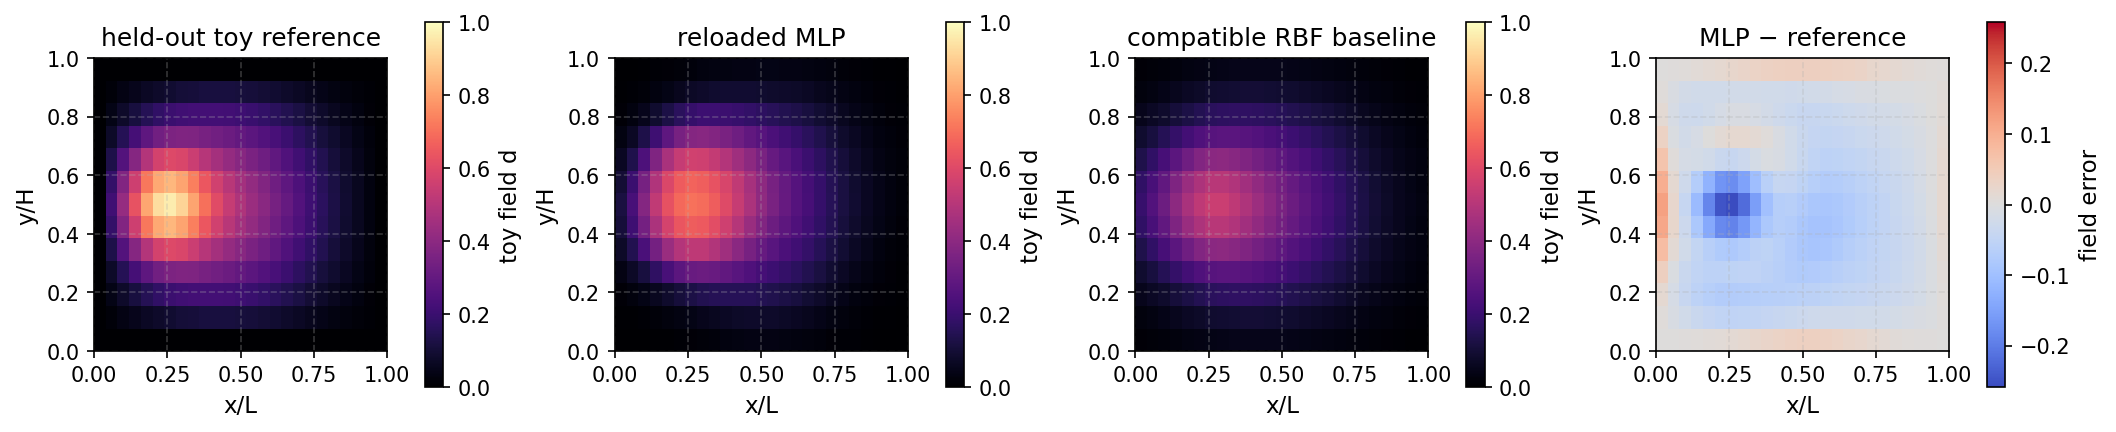

In [13]:
def field_image(values):
    return values.detach().reshape(problem.ny, problem.nx).cpu().numpy()

error = prediction_after - heldout_reference
error_limit = max(float(error.abs().max()), torch.finfo(torch.float64).eps)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), constrained_layout=True)
for ax, values, title, cmap, limits in (
    (axes[0], heldout_reference, "held-out toy reference", "magma", (0, 1)),
    (axes[1], prediction_after, "reloaded MLP", "magma", (0, 1)),
    (axes[2], rbf_prediction, "compatible RBF baseline", "magma", (0, 1)),
    (axes[3], error, "MLP − reference", "coolwarm", (-error_limit, error_limit)),
):
    image = ax.imshow(field_image(values), origin="lower", extent=(0,1,0,1), cmap=cmap, vmin=limits[0], vmax=limits[1])
    ax.set(title=title, xlabel="x/L", ylabel="y/H", aspect="equal")
    fig.colorbar(image, ax=ax, shrink=0.78, label="field error" if ax is axes[3] else "toy field d")
fig.savefig(practical_dir / "tiny_mlp_heldout_field.png", dpi=160, bbox_inches="tight")
display_figure(fig, alt="Held-out toy reference, reloaded MLP field, compatible RBF field, and MLP error.")
plt.close(fig)

### Assess a compatible proposal

`ToyDamageAdapter` checks feature order, grid signature, input shape and finite values. Its proposal also respects the scalar bounds, boundary values and supplied previous state. The relative residual is

$$\rho=\frac{\|A\widehat{\mathbf d}-\mathbf b\|_2}{\|\mathbf b\|_2+10^{-15}}.$$

The gate accepts when $\rho\le0.30$. Otherwise it computes the direct toy reference correction. Here the previous state is the reference field at the lower load 0.82.

In [14]:
adapter = ToyDamageAdapter(reloaded, metadata, problem)
load_factor = .94
d_previous = problem.reference_field(.82)
proposal = adapter.propose(problem.features(load_factor), d_previous=d_previous)
assessment = adapter.assess(proposal, load_factor, residual_limit=.30)
reference = problem.reference_field(load_factor)
corrected = proposal if assessment["accepted"] else adapter.fallback(load_factor, d_previous)
print({"assessment": assessment, "proposal_rmse": float((proposal-reference).square().mean().sqrt())})
assert assessment["accepted"], assessment

{'assessment': {'toy_relative_residual': 0.19402747874051113, 'residual_limit': 0.3, 'accepted': True, 'scope': 'Residual of the discrete ToyHelmholtzProblem'}, 'proposal_rmse': 0.029164814588982523}


### Observe the reference-correction branch

A controlled spatial perturbation provides a second proposal for the same equation and tolerance. Compare its residual with the reference correction's residual. This demonstration keeps the data, model and load fixed.

In [15]:
corrupted = torch.where(problem.boundary_mask, torch.zeros_like(proposal),
                        (proposal + .30 * torch.sin(12 * problem.coordinates[:, 0])).clamp(0, 1))
rejected = adapter.assess(corrupted, load_factor, residual_limit=.30)
fallback = adapter.fallback(load_factor, d_previous)
fallback_residual = problem.relative_residual(fallback, load_factor)
assert not rejected["accepted"], rejected
assert fallback_residual < 1.e-10
print({"perturbed_assessment": rejected, "fallback_residual": fallback_residual})

{'perturbed_assessment': {'toy_relative_residual': 1.164008876432137, 'residual_limit': 0.3, 'accepted': False, 'scope': 'Residual of the discrete ToyHelmholtzProblem'}, 'fallback_residual': 2.969565304912253e-15}


Expand the optional interface checks to see how the adapter responds to permuted feature names and a non-finite input.

In [16]:
# Explicitly demonstrate an interface failure instead of silently reshaping input.
try:
    adapter.propose(
        problem.features(load_factor),
        feature_order=("load_factor", "x_over_L", "y_over_H"),
    )
except ValueError as error:
    compatibility_message = str(error)
else:
    raise AssertionError("An incompatible feature order was unexpectedly accepted.")
print("Expected incompatibility:", compatibility_message)

nan_features = problem.features(load_factor).clone()
nan_features[0, 0] = float("nan")
try:
    adapter.propose(nan_features)
except ValueError as error:
    finiteness_message = str(error)
else:
    raise AssertionError("A non-finite adapter input was unexpectedly accepted.")
print("Expected finite-input rejection:", finiteness_message)

Expected incompatibility: Incompatible feature order. Expected ['x_over_L', 'y_over_H', 'load_factor'], got ['load_factor', 'x_over_L', 'y_over_H'].
Expected finite-input rejection: Incompatible feature tensor: all adapter inputs must be finite.


Read the complete fields alongside the residuals. A proposal can look smooth and still differ from the discrete reference; the equation check adds information about that difference.

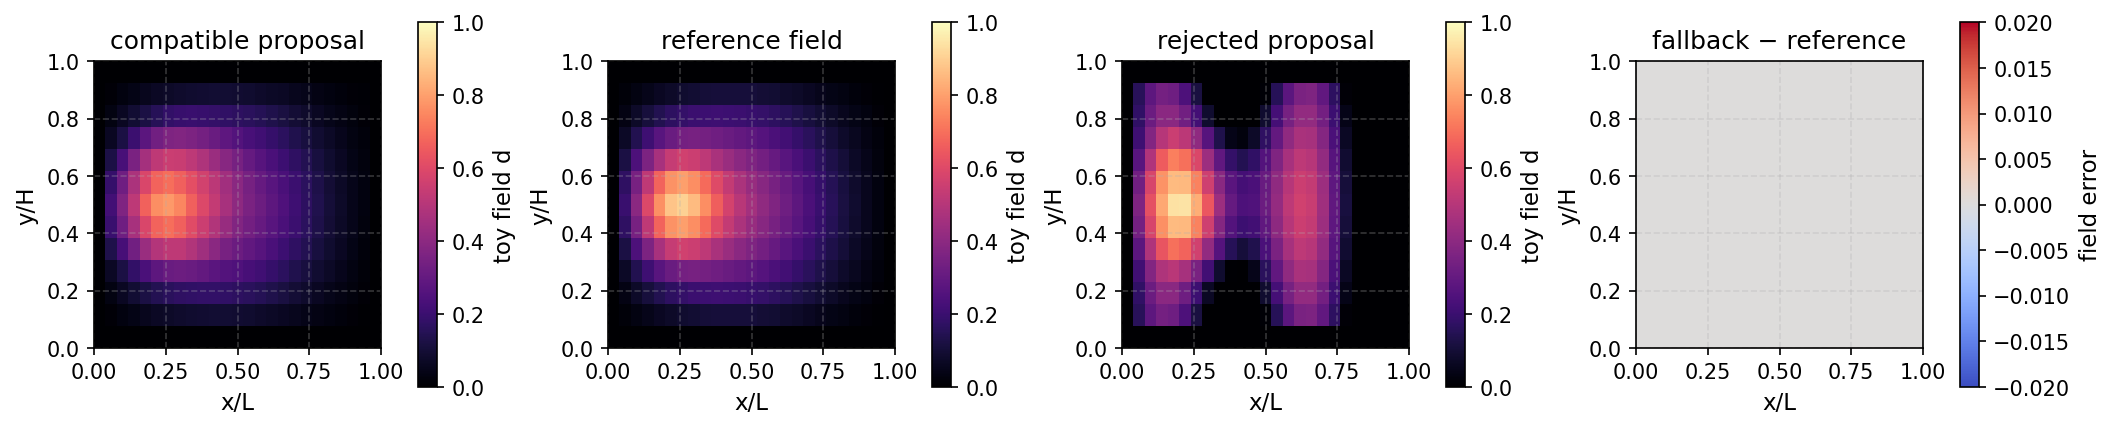

In [17]:
def field_image(values):
    return values.detach().reshape(problem.ny, problem.nx).cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), constrained_layout=True)
panels = (
    (proposal, "compatible proposal", "magma", (0, 1)),
    (reference, "reference field", "magma", (0, 1)),
    (corrupted, "rejected proposal", "magma", (0, 1)),
    (fallback - reference, "fallback − reference", "coolwarm", (-0.02, 0.02)),
)
for ax, field, title, cmap, limits in zip(axes, *zip(*panels)):
    image = ax.imshow(field_image(field), origin="lower", extent=(0,1,0,1), cmap=cmap, vmin=limits[0], vmax=limits[1])
    ax.set(title=title, xlabel="x/L", ylabel="y/H", aspect="equal")
    fig.colorbar(image, ax=ax, shrink=0.78, label="field error" if ax is axes[3] else "toy field d")
fig.savefig(practical_dir / "toy_adapter_fallback.png", dpi=160, bbox_inches="tight")
display_figure(fig, alt="Toy adapter's compatible proposal, reference, rejected proposal, and fallback error.")
plt.close(fig)

The result table links each field to its residual and selected action. In the saved NPZ, `proposal` is the model prediction, `selected` is the field returned by the acceptance check, and `fallback` is the reference solution used after rejection.

In [18]:
gate_rows = [{"case": "Compatible proposal", "residual": assessment["toy_relative_residual"], "action": "Accept"},
             {"case": "Perturbed proposal", "residual": rejected["toy_relative_residual"], "action": "Reference correction"},
             {"case": "Reference fallback", "residual": fallback_residual, "action": "Use reference solution"}]
save_table(gate_rows, practical_dir / "toy_gate_results.csv")
display(HTML(numeric_table_html(gate_rows, [("case", "Field"), ("residual", "Relative equation residual"),
                                           ("action", "Selected action")], "Residual limit = 0.30")))

Field,Relative equation residual,Selected action
Compatible proposal,0.19403,Accept
Perturbed proposal,1.164,Reference correction
Reference fallback,2.9696e-15,Use reference solution


In [19]:
np.savez_compressed(practical_dir / "toy_review_fields.npz", coordinates=problem.coordinates.numpy(),
                    heldout_load=heldout_load, heldout_reference=heldout_reference.numpy(),
                    prediction_before=prediction_before.numpy(), prediction_after=prediction_after.numpy(),
                    rbf_prediction=rbf_prediction.detach().numpy(), proposal_load=load_factor,
                    previous=d_previous.numpy(), proposal=proposal.numpy(), reference=reference.numpy(),
                    perturbed=corrupted.numpy(), selected=corrected.numpy(), fallback=fallback.numpy())

The optional export records the two decisions. A later data-aggregation activity would additionally retain the model-visited inputs and reference target arrays, retrain, and evaluate a held-out rollout.

In [20]:
# Save decision metadata for this proposal/reference assessment.
# Include reference-label cost in a later retraining comparison.
replay_record = {
    "scope": "course-owned ToyHelmholtzProblem; one offline proposal/reference correction record",
    "load_factor": load_factor,
    "feature_order": list(FEATURE_ORDER),
    "normal_assessment": assessment,
    "rejected_assessment": rejected,
    "correction": "classical ToyHelmholtzProblem reference solve",
    "heldout_evaluation_frozen": True,
}
replay_path = practical_dir / "toy_adapter_replay_record.json"
replay_path.write_text(json.dumps(replay_record, indent=2), encoding="utf-8")
print({"replay_record": str(replay_path.relative_to(COURSE_ROOT)), "decision": "accept compatible / fallback rejected"})

{'replay_record': 'assets/day2_forward/classroom/03/toy_adapter_replay_record.json', 'decision': 'accept compatible / fallback rejected'}


### Example outline · P3-R01 · A fracture-compatible hybrid

**Learning question:** Which proposed fracture state can be accepted, and when is a coupled correction needed?

**Planned content.** Follow a learned damage proposal through a coupled fracture calculation, with its history inputs and corrected fields. The Helmholtz calculation above supplies the current executable demonstration.

### Animation storyboard · P3-A01 · Proposal, check and correction

**Planned content.** Show a model proposal, its residual assessment and the accepted or corrected field. Link this sequence to Lecture 3's conceptual data-aggregation loop, with reference labelling, retraining and held-out evaluation.

## Key takeaways

- Whole-load splits and training-only normalisation define the learning experiment.
- The visible loss and backward pass connect field mismatch to every trainable weight.
- Saved weights and input conventions reconstruct the same model prediction.
- The discrete toy residual guides proposal acceptance and checked reference correction.

## Exercises

Try each question before opening the hint or worked solution. Keep the original calculation as your reference.

### Exercise 1: Connect the data layout to the training gradient

The grid contains $25\times13$ nodes. Twelve whole load cases form the training set, and each node supplies the feature row $[x/L,y/H,\lambda]$ and one target value.

1. Determine the shapes of the combined training-feature and target tensors.
2. For $\mathcal L=M^{-1}\sum_i(\widehat d_i-d_i)^2$, derive $\partial\mathcal L/\partial\widehat d_i$ and use the chain rule to express $\nabla_{\boldsymbol\theta}\mathcal L$.
3. Explain why normalisation statistics are fitted on training inputs and reused for validation and test inputs. How does keeping whole load cases together affect the interpretation of test accuracy?

::::{admonition} Hint 1
:class: dropdown course-hint

Count all nodewise rows across the training loads. Differentiate one squared error, then propagate that derivative through the network output. Think of normalisation as part of the model's input interface.
::::

::::{admonition} Worked solution 1
:class: dropdown course-solution

There are $N=25\times13=325$ nodes per load and $M=12N=3900$ training rows. The feature tensor has shape $(3900,3)$ and the target tensor has shape $(3900,1)$.

For each row,

$$
\frac{\partial\mathcal L}{\partial\widehat d_i}
=\frac{2}{M}(\widehat d_i-d_i),
\qquad
\nabla_{\boldsymbol\theta}\mathcal L
=\sum_{i=1}^{M}\frac{2}{M}(\widehat d_i-d_i)
\nabla_{\boldsymbol\theta}f_{\boldsymbol\theta}(\mathbf z_i).
$$

The visible training loop computes these derivatives with `loss.backward()`. Adam then updates the parameters using the accumulated gradients.

Training-only statistics define a fixed transformation available when the model is deployed. Reusing them gives validation, test, and future inputs the same meaning. Keeping every node from one load case in a single split evaluates a new loading condition; randomly splitting nodes within one field also measures interpolation inside a field already represented during training. Here $z_i$ denotes the normalised feature row for training sample $i$, containing position and load.
::::

### Exercise 2: Explore the residual tolerance

Use the existing `proposal`, `reference`, `adapter`, and `d_previous` variables to compare tolerances $0.05$, $0.15$, and $0.30$ in a new cell.

1. Record whether the proposal is accepted at each tolerance.
2. Compute the selected field's RMSE against the reference and its residual.
3. Describe the relationship between tolerance, field accuracy, and use of the reference solver. Which quantities would you time before evaluating the computational benefit of the complete workflow?

::::{admonition} Hint 2
:class: dropdown course-hint

Call `adapter.assess(proposal, load_factor, residual_limit=tolerance)`. Select `proposal` when accepted and `adapter.fallback(load_factor, d_previous)` otherwise. Preserve the original demonstration cell and perform this sweep in a separate cell.
::::

::::{admonition} Worked solution 2
:class: dropdown course-solution

This sweep uses the existing proposal and evaluates the complete selection rule:

```python
for tolerance in (0.05, 0.15, 0.30):
    decision = adapter.assess(
        proposal, load_factor, residual_limit=tolerance
    )
    selected = (
        proposal if decision["accepted"]
        else adapter.fallback(load_factor, d_previous)
    )
    print({
        "tolerance": tolerance,
        "accepted": decision["accepted"],
        "selected_rmse": float((selected - reference).square().mean().sqrt()),
        "selected_residual": problem.relative_residual(selected, load_factor),
    })
```

For a fixed proposal, increasing the tolerance can change a rejection into acceptance. The reference branch computes the direct solution of this discrete field problem; the accepted branch retains the model approximation. Interpret the differences using the printed RMSE and residual, and inspect the corresponding spatial error.

An end-to-end timing study includes feature preparation, prediction, projection, residual evaluation, and every reference correction. Report the reference-only baseline on the same inputs and hardware. A training or data-aggregation study additionally accounts for reference-label generation and retraining.
::::

## Continue studying

[Detailed notebook 04](https://github.com/CEMS-Lab/autumn-school/blob/main/notebooks/04_train_save_reload_adapter.ipynb) · [Detailed notebook 05](https://github.com/CEMS-Lab/autumn-school/blob/main/notebooks/05_hybrid_reference_correction.ipynb)

The complete source, attribution and bundled licences remain in the [course repository](https://github.com/CEMS-Lab/autumn-school/blob/main/ATTRIBUTION.md).

### Session timing

Elapsed session time includes reading and pauses between cells. The course runner measures uninterrupted computation separately from installation.

In [21]:
session_seconds = time.perf_counter() - session_started
print({"setup_seconds": setup_receipt["setup_seconds"],
       "elapsed_session_seconds": round(session_seconds, 2),
       "environment": setup_receipt["environment"], "torch": torch.__version__})

{'setup_seconds': 0.744, 'elapsed_session_seconds': 3.33, 'environment': 'local', 'torch': '2.8.0'}
